In [1]:
# 1. SETUP
import os
import time
import pyspark.sql.functions as fn
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, udf, expr, current_timestamp, count, avg
from pyspark.sql.types import StringType
from IPython.display import clear_output

spark = SparkSession.builder \
    .master("local[2]") \
    .appName("WarzoneDistressStream_DATEADDED") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "2") \
    .getOrCreate()

STREAM_PATH = "/home/jovyan/labs/project_work/gdelt_stream"
OUTPUT_PATH = "/home/jovyan/labs/project_work/gdelt_output"
os.makedirs(STREAM_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"Streaming path: {STREAM_PATH}")
print(f"Output path   : {OUTPUT_PATH}")

Streaming path: /home/jovyan/labs/project_work/gdelt_stream
Output path   : /home/jovyan/labs/project_work/gdelt_output


In [2]:
# 2. DISTRESS LOGIC

def classify_distress(event_code, tone):
    if tone is not None and tone < -3:
        return "CRITICAL"
    elif tone is not None and tone < -1:
        return "MONITORED EVENT"
    return "STABLE"

distress_udf = udf(classify_distress, StringType())

In [3]:
# 3. READ STREAM

raw_stream = spark.readStream \
    .format("text") \
    .option("maxFilesPerTrigger", 1) \
    .load(STREAM_PATH)

print("Raw stream created")

Raw stream created


In [4]:
# 4. QUICK STATIC CHECK TO FIND THE CORRECT DATEADDED INDEX
test_df = spark.read.text(STREAM_PATH)

test_fields = test_df.select(split(col("value"), "\t").alias("fields"))

print("Sample field counts:")
test_fields.selectExpr("size(fields) as field_count").show(5, truncate=False)

Sample field counts:
+-----------+
|field_count|
+-----------+
|61         |
|61         |
|61         |
|61         |
|61         |
+-----------+
only showing top 5 rows


In [6]:
DATEADDED_INDEX = 59 

In [7]:
# 6. SANITY CHECK PARSING USING DATEADDED
test_parsed = test_df.select(
    split(col("value"), "\t").getItem(26).alias("EventCode"),
    split(col("value"), "\t").getItem(54).alias("Country"),
    expr("try_cast(split(value, '\t')[34] as float)").alias("Tone"),
    expr("try_cast(split(value, '\t')[35] as float)").alias("Goldstein"),
    expr("try_cast(split(value, '\t')[30] as int)").alias("Mentions"),
    split(col("value"), "\t").getItem(DATEADDED_INDEX).alias("raw_dateadded"),
    fn.to_timestamp(
        split(col("value"), "\t").getItem(DATEADDED_INDEX),
        "yyyyMMddHHmmss"
    ).alias("event_time")
)

print("Sample DATEADDED parsing:")
test_parsed.select(
    "raw_dateadded", "event_time", "Country", "Tone", "Goldstein", "Mentions"
).show(10, truncate=False)

null_count = test_parsed.filter(col("event_time").isNull()).count()
total_count = test_parsed.count()

print(f"Total rows      : {total_count}")
print(f"Null event_time : {null_count}")

test_parsed.agg(
    fn.min("event_time").alias("earliest_event_time"),
    fn.max("event_time").alias("latest_event_time")
).show(truncate=False)

if total_count > 0 and null_count == 0:
    print("DATEADDED parsing looks correct")
else:
    print("DATEADDED parsing has an issue — recheck DATEADDED_INDEX")

Sample DATEADDED parsing:
+--------------+-------------------+-------+----------+---------+--------+
|raw_dateadded |event_time         |Country|Tone      |Goldstein|Mentions|
+--------------+-------------------+-------+----------+---------+--------+
|20260408160000|2026-04-08 16:00:00|US     |0.5780347 |1.0      |NULL    |
|20260408160000|2026-04-08 16:00:00|US     |0.5780347 |1.0      |NULL    |
|20260408160000|2026-04-08 16:00:00|US     |0.5780347 |4.0      |NULL    |
|20260408160000|2026-04-08 16:00:00|US     |0.5780347 |1.0      |NULL    |
|20260408160000|2026-04-08 16:00:00|US     |-4.730832 |0.0      |NULL    |
|20260408160000|2026-04-08 16:00:00|UK     |-2.4110217|0.0      |NULL    |
|20260408160000|2026-04-08 16:00:00|UK     |-2.4110217|0.0      |NULL    |
|20260408160000|2026-04-08 16:00:00|US     |1.0362694 |0.0      |NULL    |
|20260408160000|2026-04-08 16:00:00|UK     |-4.730832 |1.0      |NULL    |
|20260408160000|2026-04-08 16:00:00|US     |-6.480447 |1.0      |NULL    |

In [8]:
# 7. CREATE THE PROCESSED STREAM
processed_stream = raw_stream.select(
    split(col("value"), "\t").getItem(26).alias("EventCode"),
    split(col("value"), "\t").getItem(54).alias("Country"),
    expr("try_cast(split(value, '\t')[34] as float)").alias("Tone"),
    expr("try_cast(split(value, '\t')[35] as float)").alias("Goldstein"),
    expr("try_cast(split(value, '\t')[30] as int)").alias("Mentions"),
    expr("try_cast(split(value, '\t')[40] as float)").alias("Lat"),
    expr("try_cast(split(value, '\t')[41] as float)").alias("Long"),
    split(col("value"), "\t").getItem(60).alias("URL"),
    split(col("value"), "\t").getItem(DATEADDED_INDEX).alias("DATEADDED_raw"),
    fn.to_timestamp(
        split(col("value"), "\t").getItem(DATEADDED_INDEX),
        "yyyyMMddHHmmss"
    ).alias("event_time"),
    current_timestamp().alias("processing_time")
).withColumn(
    "DistressStatus",
    distress_udf(col("EventCode"), col("Tone"))
).filter(
    col("event_time").isNotNull()
).filter(
    col("Country").isNotNull()
)

print("Processed stream created")

Processed stream created


In [9]:
# 8. STOP OLD STREAMS BEFORE STARTING NEW ONES
stream_names = [
    "counts_distress",
    "counts_country",
    "counts_breakdown",
    "event_window_15m_country",
    "event_window_15m_country_distress",
    "proc_window_country",
    "proc_window_distress"
]

for q in spark.streams.active:
    if q.name in stream_names:
        print(f"Stopping old stream: {q.name}")
        q.stop()

time.sleep(3)
print("Old streams cleared")

Old streams cleared


In [10]:
# 9. RUNNING TOTALS
agg_distress = processed_stream \
    .groupBy("DistressStatus") \
    .count()

agg_country = processed_stream \
    .groupBy("Country") \
    .agg(
        count("*").alias("event_count"),
        fn.round(avg("Tone"), 2).alias("avg_tone"),
        fn.round(avg("Goldstein"), 2).alias("avg_goldstein")
    )

agg_breakdown = processed_stream \
    .groupBy("Country", "DistressStatus") \
    .agg(
        count("*").alias("event_count"),
        fn.round(avg("Tone"), 2).alias("avg_tone")
    )

q_distress = agg_distress.writeStream \
    .format("memory") \
    .queryName("counts_distress") \
    .outputMode("complete") \
    .start()

q_country = agg_country.writeStream \
    .format("memory") \
    .queryName("counts_country") \
    .outputMode("complete") \
    .start()

q_breakdown = agg_breakdown.writeStream \
    .format("memory") \
    .queryName("counts_breakdown") \
    .outputMode("complete") \
    .start()

print("Running total streams started")

Running total streams started


In [11]:
# 10. EVENT-TIME WINDOWS USING DATEADDED

# Watermark = 2 hours
# Window     = 15 minutes

event_window_15m_country = processed_stream \
    .withWatermark("event_time", "2 hours") \
    .groupBy(
        fn.window("event_time", "15 minutes"),
        col("Country")
    ).agg(
        count("*").alias("event_count"),
        fn.round(avg("Tone"), 2).alias("avg_tone"),
        fn.round(avg("Goldstein"), 2).alias("avg_goldstein"),
        fn.round(avg("Mentions"), 2).alias("avg_mentions")
    )

event_window_15m_country_distress = processed_stream \
    .withWatermark("event_time", "2 hours") \
    .groupBy(
        fn.window("event_time", "15 minutes"),
        col("Country"),
        col("DistressStatus")
    ).agg(
        count("*").alias("event_count"),
        fn.round(avg("Tone"), 2).alias("avg_tone"),
        fn.round(avg("Goldstein"), 2).alias("avg_goldstein"),
        fn.round(avg("Mentions"), 2).alias("avg_mentions")
    )

q_event_country = event_window_15m_country.writeStream \
    .format("memory") \
    .queryName("event_window_15m_country") \
    .outputMode("append") \
    .start()

q_event_distress = event_window_15m_country_distress.writeStream \
    .format("memory") \
    .queryName("event_window_15m_country_distress") \
    .outputMode("append") \
    .start()

print("15-minute event-time streams started")

15-minute event-time streams started


In [12]:
# 11. OPTIONAL: PROCESSING-TIME WINDOWS
proc_window_country = processed_stream \
    .groupBy(
        fn.window("processing_time", "60 seconds"),
        col("Country")
    ).agg(
        count("*").alias("event_count"),
        fn.round(avg("Tone"), 2).alias("avg_tone"),
        fn.round(avg("Goldstein"), 2).alias("avg_goldstein")
    )

proc_window_distress = processed_stream \
    .groupBy(
        fn.window("processing_time", "60 seconds"),
        col("Country"),
        col("DistressStatus")
    ).agg(
        count("*").alias("event_count"),
        fn.round(avg("Tone"), 2).alias("avg_tone")
    )

q_proc_country = proc_window_country.writeStream \
    .format("memory") \
    .queryName("proc_window_country") \
    .outputMode("complete") \
    .start()

q_proc_distress = proc_window_distress.writeStream \
    .format("memory") \
    .queryName("proc_window_distress") \
    .outputMode("complete") \
    .start()

print("Processing-time streams started")

Processing-time streams started


In [13]:
# 12. PREVIEW QUERIES FOR VISUALIZATION
print("15-minute event-time trend by country")
spark.sql("""
    SELECT
        window.start AS window_start,
        window.end AS window_end,
        date_format(window.start, 'MMM-dd HH:mm') AS time_label,
        Country,
        event_count,
        avg_tone,
        avg_goldstein,
        avg_mentions
    FROM event_window_15m_country
    ORDER BY window.start, Country
""").show(50, truncate=False)

print("15-minute event-time trend by country + distress")
spark.sql("""
    SELECT
        window.start AS window_start,
        window.end AS window_end,
        date_format(window.start, 'MMM-dd HH:mm') AS time_label,
        Country,
        DistressStatus,
        event_count,
        avg_tone,
        avg_goldstein,
        avg_mentions
    FROM event_window_15m_country_distress
    ORDER BY window.start, Country, DistressStatus
""").show(50, truncate=False)

15-minute event-time trend by country
+-------------------+-------------------+------------+-------+-----------+--------+-------------+------------+
|window_start       |window_end         |time_label  |Country|event_count|avg_tone|avg_goldstein|avg_mentions|
+-------------------+-------------------+------------+-------+-----------+--------+-------------+------------+
|2026-04-08 05:15:00|2026-04-08 05:30:00|Apr-08 05:15|IN     |3          |4.78    |1.0          |NULL        |
|2026-04-08 05:15:00|2026-04-08 05:30:00|Apr-08 05:15|IS     |16         |-2.94   |2.38         |NULL        |
|2026-04-08 05:15:00|2026-04-08 05:30:00|Apr-08 05:15|IZ     |2          |1.33    |1.0          |NULL        |
|2026-04-08 05:15:00|2026-04-08 05:30:00|Apr-08 05:15|LY     |1          |-4.41   |1.0          |NULL        |
|2026-04-08 05:15:00|2026-04-08 05:30:00|Apr-08 05:15|RS     |6          |-5.01   |2.0          |NULL        |
|2026-04-08 05:15:00|2026-04-08 05:30:00|Apr-08 05:15|UK     |2          |

In [18]:
# 13. LIVE DASHBOARD LOOP
print("Dashboard running. Press STOP in Jupyter to stop.\n")

try:
    while True:
        clear_output(wait=True)
        print("Live dashboard — press STOP to exit\n")

        print("Running total by Distress Status")
        spark.sql("""
            SELECT DistressStatus, count
            FROM counts_distress
            ORDER BY count DESC
        """).show(truncate=False)

        print("Running total by Country")
        spark.sql("""
            SELECT Country, event_count, avg_tone, avg_goldstein
            FROM counts_country
            ORDER BY event_count DESC
        """).show(truncate=False)

        print("Country × Distress breakdown")
        spark.sql("""
            SELECT Country, DistressStatus, event_count, avg_tone
            FROM counts_breakdown
            ORDER BY Country, event_count DESC
        """).show(truncate=False)

        print("Event-time 15-minute trend by country")
        spark.sql("""
            SELECT
                date_format(window.start, 'MMM-dd HH:mm') AS window_start,
                date_format(window.end, 'MMM-dd HH:mm') AS window_end,
                Country,
                event_count,
                avg_tone,
                avg_goldstein,
                avg_mentions
            FROM event_window_15m_country
            ORDER BY window.start, Country
        """).show(50, truncate=False)

        print("Event-time 15-minute trend by country + distress")
        spark.sql("""
            SELECT
                date_format(window.start, 'MMM-dd HH:mm') AS window_start,
                date_format(window.end, 'MMM-dd HH:mm') AS window_end,
                Country,
                DistressStatus,
                event_count,
                avg_tone,
                avg_goldstein,
                avg_mentions
            FROM event_window_15m_country_distress
            ORDER BY window.start, Country, DistressStatus
        """).show(50, truncate=False)

        time.sleep(15)

except KeyboardInterrupt:
    print("Dashboard stopped")

Live dashboard — press STOP to exit

Running total by Distress Status
+---------------+-----+
|DistressStatus |count|
+---------------+-----+
|CRITICAL       |546  |
|STABLE         |385  |
|MONITORED EVENT|322  |
+---------------+-----+

Running total by Country
+-------+-----------+--------+-------------+
|Country|event_count|avg_tone|avg_goldstein|
+-------+-----------+--------+-------------+
|IS     |455        |-4.04   |1.78         |
|US     |402        |-1.08   |1.54         |
|UK     |213        |-2.32   |1.2          |
|RS     |103        |-3.76   |1.41         |
|IN     |65         |-1.29   |1.11         |
|GZ     |6          |-4.45   |3.0          |
|IZ     |6          |-0.38   |1.0          |
|YM     |2          |-2.29   |1.0          |
|LY     |1          |-4.41   |1.0          |
+-------+-----------+--------+-------------+

Country × Distress breakdown
+-------+---------------+-----------+--------+
|Country|DistressStatus |event_count|avg_tone|
+-------+---------------+--

In [19]:
# 14. SAVE RESULTS TO CSV
import pandas as pd

tables = {
    "final_distress_totals": """
        SELECT * FROM counts_distress ORDER BY count DESC
    """,
    "final_country_totals": """
        SELECT * FROM counts_country ORDER BY event_count DESC
    """,
    "final_country_breakdown": """
        SELECT * FROM counts_breakdown ORDER BY Country, event_count DESC
    """,
    "final_event_window_15m_country": """
        SELECT
            window.start AS window_start,
            window.end AS window_end,
            date_format(window.start, 'MMM-dd HH:mm') AS time_label,
            Country,
            event_count,
            avg_tone,
            avg_goldstein,
            avg_mentions
        FROM event_window_15m_country
        ORDER BY window.start, Country
    """,
    "final_event_window_15m_country_distress": """
        SELECT
            window.start AS window_start,
            window.end AS window_end,
            date_format(window.start, 'MMM-dd HH:mm') AS time_label,
            Country,
            DistressStatus,
            event_count,
            avg_tone,
            avg_goldstein,
            avg_mentions
        FROM event_window_15m_country_distress
        ORDER BY window.start, Country, DistressStatus
    """
}

print("Saving results...")
for filename, query in tables.items():
    try:
        df = spark.sql(query).toPandas()
        out_file = f"{OUTPUT_PATH}/{filename}.csv"
        df.to_csv(out_file, index=False)
        print(f"Saved: {out_file} ({len(df)} rows)")
    except Exception as e:
        print(f"Skipped {filename}: {e}")

Saving results...
Saved: /home/jovyan/labs/project_work/gdelt_output/final_distress_totals.csv (3 rows)
Saved: /home/jovyan/labs/project_work/gdelt_output/final_country_totals.csv (9 rows)
Saved: /home/jovyan/labs/project_work/gdelt_output/final_country_breakdown.csv (20 rows)
Saved: /home/jovyan/labs/project_work/gdelt_output/final_event_window_15m_country.csv (73 rows)
Saved: /home/jovyan/labs/project_work/gdelt_output/final_event_window_15m_country_distress.csv (166 rows)


In [20]:
# 15. STOP ALL STREAMS
print("Stopping all active streams...")
for q in spark.streams.active:
    q.stop()

print("All streams stopped")

Stopping all active streams...
All streams stopped


In [17]:
spark.sql("""
    SELECT
        date_format(window.start, 'MMM-dd HH:mm') AS window_start,
        Country,
        event_count
    FROM event_window_15m_country
    ORDER BY window.start, Country
""").show(30, truncate=False)

+------------+-------+-----------+
|window_start|Country|event_count|
+------------+-------+-----------+
|Apr-08 05:15|IN     |3          |
|Apr-08 05:15|IS     |16         |
|Apr-08 05:15|IZ     |2          |
|Apr-08 05:15|LY     |1          |
|Apr-08 05:15|RS     |6          |
|Apr-08 05:15|UK     |2          |
|Apr-08 05:15|US     |30         |
|Apr-08 05:15|YM     |2          |
|Apr-08 05:30|IN     |18         |
|Apr-08 05:30|IS     |81         |
|Apr-08 05:30|IZ     |4          |
|Apr-08 05:30|RS     |21         |
|Apr-08 05:30|UK     |9          |
|Apr-08 05:30|US     |24         |
|Apr-08 05:45|IN     |4          |
|Apr-08 05:45|IS     |9          |
|Apr-08 05:45|RS     |1          |
|Apr-08 05:45|UK     |7          |
|Apr-08 05:45|US     |13         |
|Apr-08 14:45|GZ     |2          |
|Apr-08 14:45|IN     |2          |
|Apr-08 14:45|IS     |55         |
|Apr-08 14:45|RS     |11         |
|Apr-08 14:45|UK     |16         |
|Apr-08 14:45|US     |24         |
|Apr-08 15:00|IN    

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. LOAD FILES
# ==============================
base_path = "/home/jovyan/labs/project_work/gdelt_output"

event_country = pd.read_csv(f"{base_path}/final_event_window_15m_country.csv")
event_distress = pd.read_csv(f"{base_path}/final_event_window_15m_country_distress.csv")
country_totals = pd.read_csv(f"{base_path}/final_country_totals.csv")
country_breakdown = pd.read_csv(f"{base_path}/final_country_breakdown.csv")
distress_totals = pd.read_csv(f"{base_path}/final_distress_totals.csv")

print("Files loaded successfully")
print(event_country.head())
print(event_distress.head())
print(country_totals.head())
print(country_breakdown.head())
print(distress_totals.head())

Files loaded successfully
          window_start           window_end    time_label Country  \
0  2026-04-08 05:15:00  2026-04-08 05:30:00  Apr-08 05:15      IN   
1  2026-04-08 05:15:00  2026-04-08 05:30:00  Apr-08 05:15      IS   
2  2026-04-08 05:15:00  2026-04-08 05:30:00  Apr-08 05:15      IZ   
3  2026-04-08 05:15:00  2026-04-08 05:30:00  Apr-08 05:15      LY   
4  2026-04-08 05:15:00  2026-04-08 05:30:00  Apr-08 05:15      RS   

   event_count  avg_tone  avg_goldstein  avg_mentions  
0            3      4.78           1.00           NaN  
1           16     -2.94           2.38           NaN  
2            2      1.33           1.00           NaN  
3            1     -4.41           1.00           NaN  
4            6     -5.01           2.00           NaN  
          window_start           window_end    time_label Country  \
0  2026-04-08 05:15:00  2026-04-08 05:30:00  Apr-08 05:15      IN   
1  2026-04-08 05:15:00  2026-04-08 05:30:00  Apr-08 05:15      IS   
2  2026-04-08 05

Top countries: ['IS', 'US', 'UK', 'RS', 'IN']


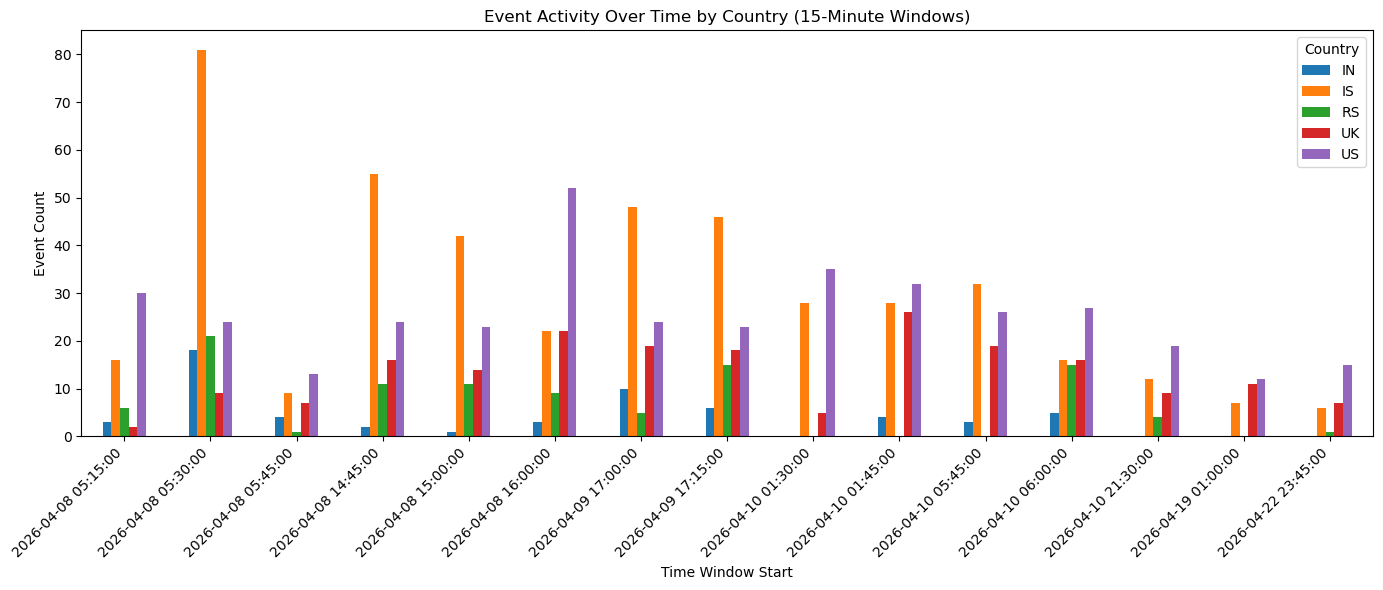

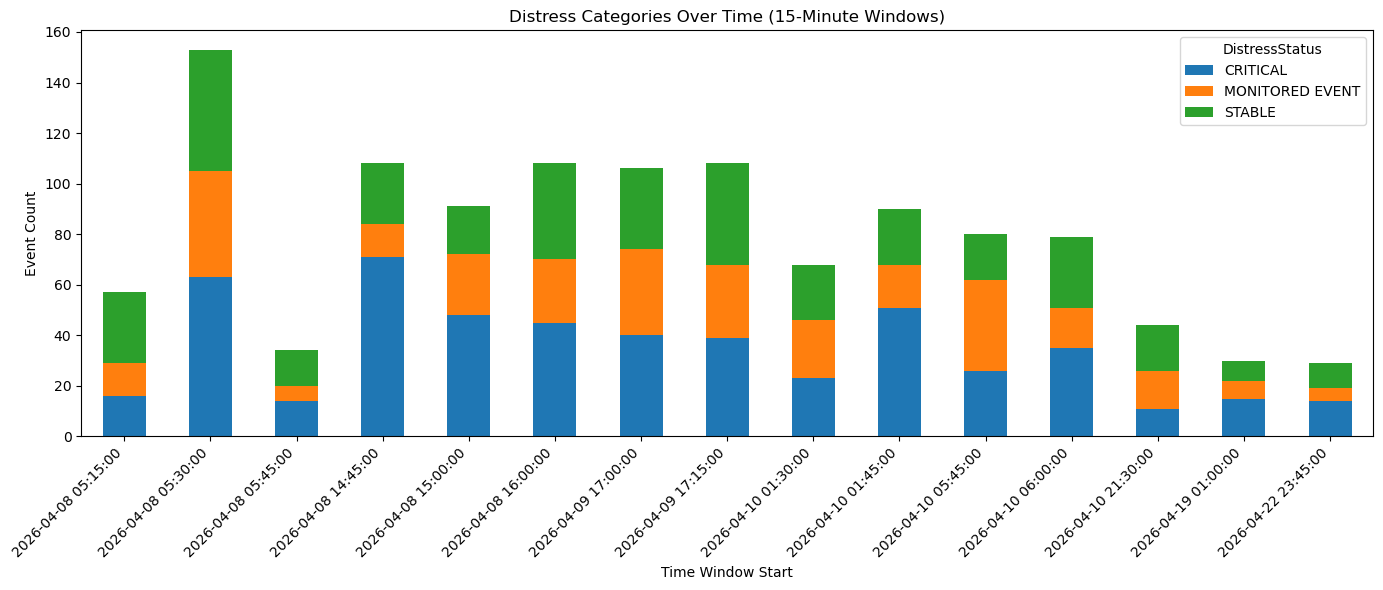

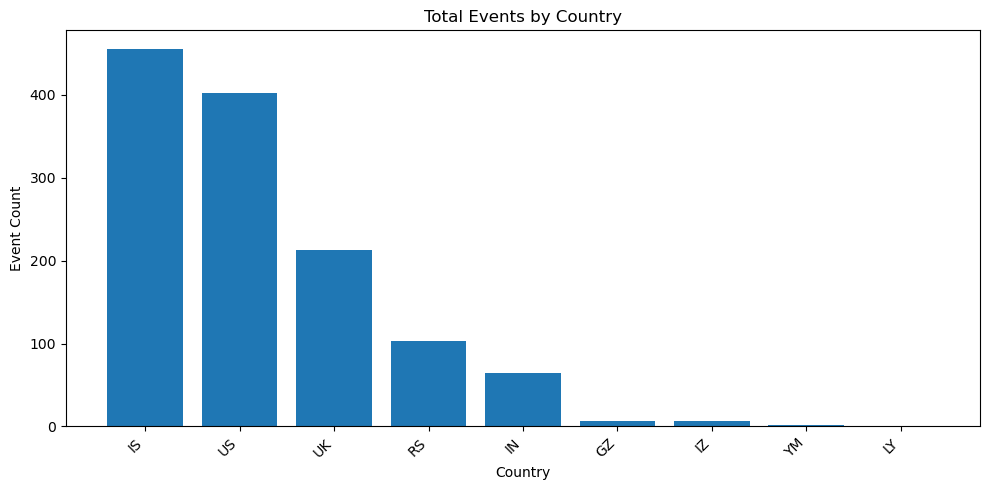

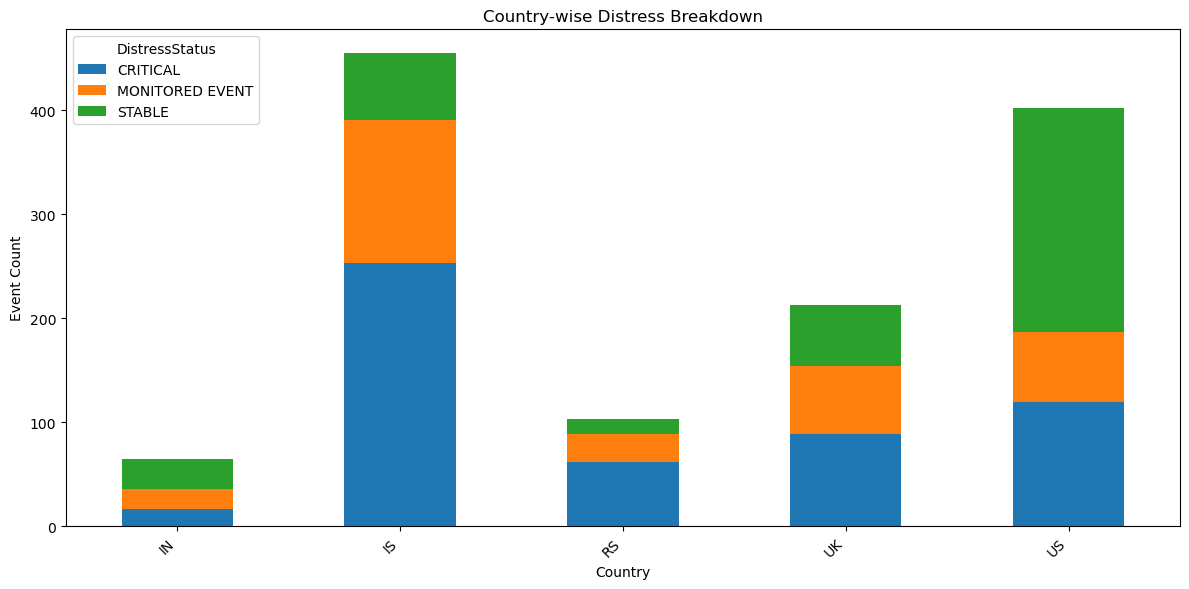

In [26]:
#Visualizations
import pandas as pd
import matplotlib.pyplot as plt

base_path = "/home/jovyan/labs/project_work/gdelt_output"

event_country = pd.read_csv(f"{base_path}/final_event_window_15m_country.csv")
event_distress = pd.read_csv(f"{base_path}/final_event_window_15m_country_distress.csv")
country_totals = pd.read_csv(f"{base_path}/final_country_totals.csv")
country_breakdown = pd.read_csv(f"{base_path}/final_country_breakdown.csv")
distress_totals = pd.read_csv(f"{base_path}/final_distress_totals.csv")

event_country["window_start"] = pd.to_datetime(event_country["window_start"])
event_country["window_end"] = pd.to_datetime(event_country["window_end"])

event_distress["window_start"] = pd.to_datetime(event_distress["window_start"])
event_distress["window_end"] = pd.to_datetime(event_distress["window_end"])

top_countries = (
    country_totals.sort_values("event_count", ascending=False)
    .head(5)["Country"]
    .tolist()
)

event_country_top = event_country[event_country["Country"].isin(top_countries)].copy()
event_distress_top = event_distress[event_distress["Country"].isin(top_countries)].copy()
country_breakdown_top = country_breakdown[country_breakdown["Country"].isin(top_countries)].copy()

print("Top countries:", top_countries)

# Chart 1: time vs country
pivot_country_time = event_country_top.pivot_table(
    index="window_start",
    columns="Country",
    values="event_count",
    aggfunc="sum",
    fill_value=0
).sort_index()

pivot_country_time.plot(kind="bar", figsize=(14, 6))
plt.title("Event Activity Over Time by Country (15-Minute Windows)")
plt.xlabel("Time Window Start")
plt.ylabel("Event Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Chart 2: time vs distress
distress_over_time = event_distress_top.groupby(
    ["window_start", "DistressStatus"]
)["event_count"].sum().reset_index()

pivot_distress_time = distress_over_time.pivot_table(
    index="window_start",
    columns="DistressStatus",
    values="event_count",
    aggfunc="sum",
    fill_value=0
).sort_index()

pivot_distress_time.plot(kind="bar", stacked=True, figsize=(14, 6))
plt.title("Distress Categories Over Time (15-Minute Windows)")
plt.xlabel("Time Window Start")
plt.ylabel("Event Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Chart 3: country totals
country_totals_sorted = country_totals.sort_values("event_count", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(country_totals_sorted["Country"], country_totals_sorted["event_count"])
plt.title("Total Events by Country")
plt.xlabel("Country")
plt.ylabel("Event Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Chart 4: country vs distress
pivot_country_distress = country_breakdown_top.pivot_table(
    index="Country",
    columns="DistressStatus",
    values="event_count",
    aggfunc="sum",
    fill_value=0
)

pivot_country_distress.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Country-wise Distress Breakdown")
plt.xlabel("Country")
plt.ylabel("Event Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

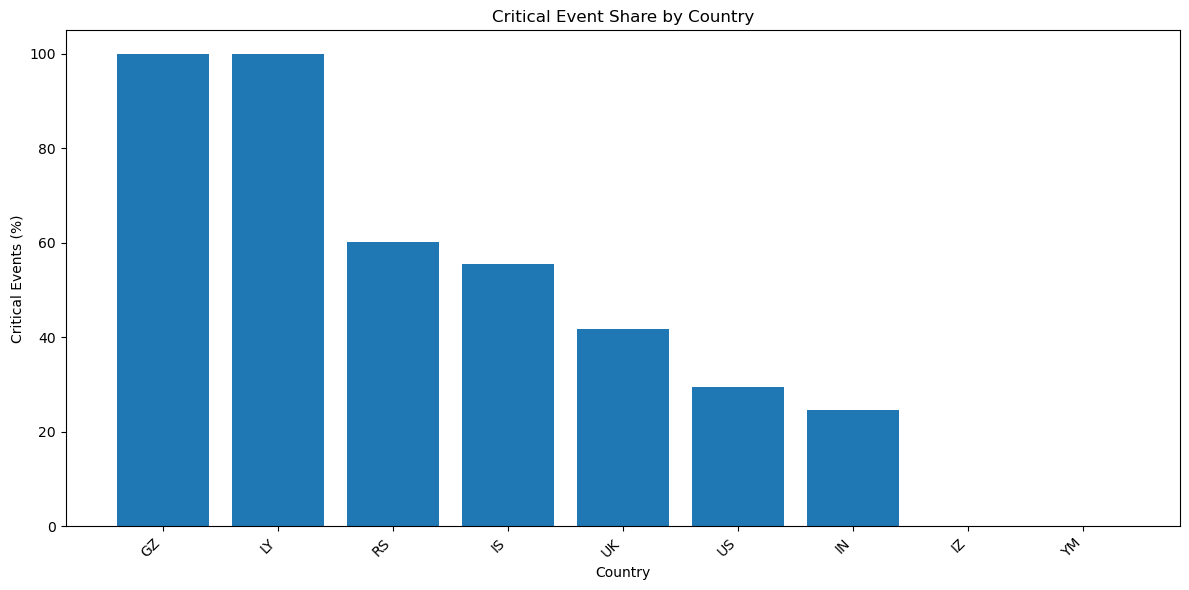

Interpretation:
This chart shows which countries have the highest proportion of CRITICAL events, not just the highest raw event volume.
Implication:
A country with fewer total events but a high critical share may still require attention because its activity is more severe.


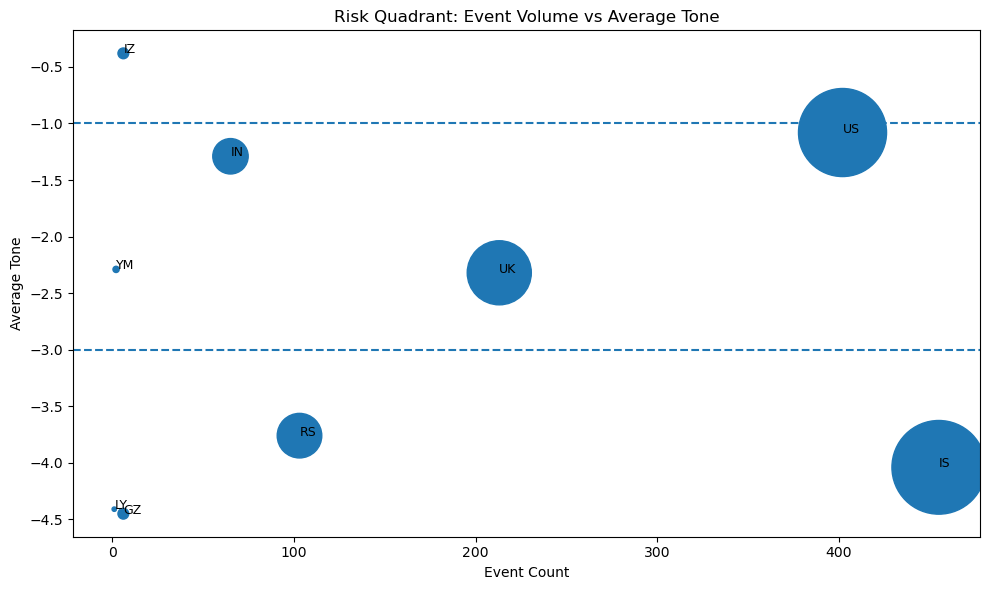

Interpretation:
Countries with high event volume and more negative average tone are stronger indicators of instability.
Implication:
This helps separate countries that are simply active in the news from countries showing more negative or crisis-like signals.


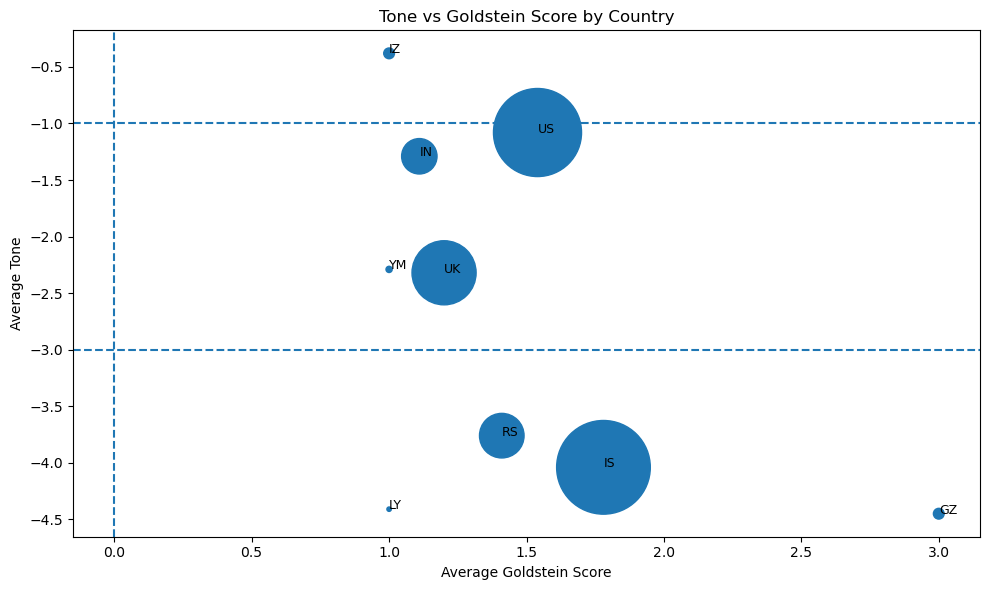

Interpretation:
Tone captures how negative the reporting is, while Goldstein captures the conflict/cooperation nature of the event.
Implication:
Countries with both negative tone and negative Goldstein scores may represent stronger geopolitical or humanitarian concern.


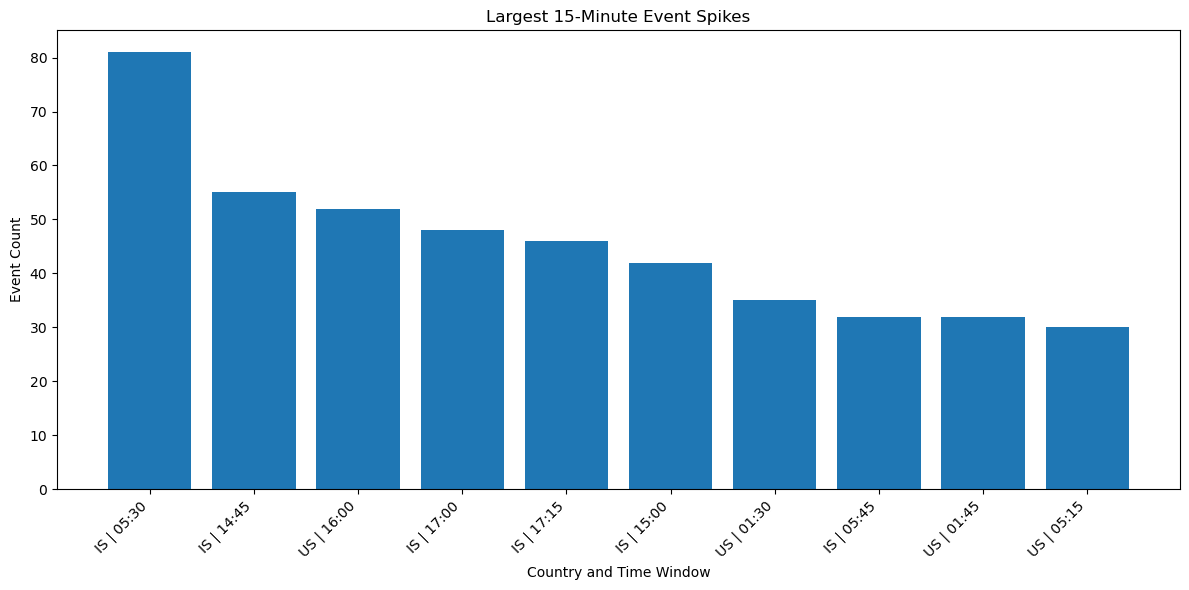

Interpretation:
This chart identifies sudden bursts of activity within short 15-minute windows.
Implication:
Sharp spikes may indicate breaking events, rapidly escalating situations, or high media attention that analysts should review quickly.


In [1]:
# ============================================
# ADDITIONAL VISUALIZATIONS FOR INTERPRETATION
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

base_path = "/home/jovyan/labs/project_work/gdelt_output"

event_country = pd.read_csv(f"{base_path}/final_event_window_15m_country.csv")
event_distress = pd.read_csv(f"{base_path}/final_event_window_15m_country_distress.csv")
country_totals = pd.read_csv(f"{base_path}/final_country_totals.csv")
country_breakdown = pd.read_csv(f"{base_path}/final_country_breakdown.csv")
distress_totals = pd.read_csv(f"{base_path}/final_distress_totals.csv")

event_country["window_start"] = pd.to_datetime(event_country["window_start"])
event_distress["window_start"] = pd.to_datetime(event_distress["window_start"])

# Use top 10 countries to keep charts readable
top_countries = (
    country_totals.sort_values("event_count", ascending=False)
    .head(10)["Country"]
    .tolist()
)

country_totals_top = country_totals[country_totals["Country"].isin(top_countries)]
country_breakdown_top = country_breakdown[country_breakdown["Country"].isin(top_countries)]
event_country_top = event_country[event_country["Country"].isin(top_countries)]
event_distress_top = event_distress[event_distress["Country"].isin(top_countries)]


# ------------------------------------------------
# Chart 5: Critical Event Share by Country
# ------------------------------------------------

critical_share = country_breakdown_top.pivot_table(
    index="Country",
    columns="DistressStatus",
    values="event_count",
    aggfunc="sum",
    fill_value=0
)

critical_share["total_events"] = critical_share.sum(axis=1)

if "CRITICAL" not in critical_share.columns:
    critical_share["CRITICAL"] = 0

critical_share["critical_share_pct"] = (
    critical_share["CRITICAL"] / critical_share["total_events"] * 100
)

critical_share = critical_share.sort_values("critical_share_pct", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(critical_share.index, critical_share["critical_share_pct"])
plt.title("Critical Event Share by Country")
plt.xlabel("Country")
plt.ylabel("Critical Events (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("This chart shows which countries have the highest proportion of CRITICAL events, not just the highest raw event volume.")
print("Implication:")
print("A country with fewer total events but a high critical share may still require attention because its activity is more severe.")


# ------------------------------------------------
# Chart 6: Risk Quadrant — Event Volume vs Avg Tone
# ------------------------------------------------

risk_df = country_totals_top.copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    risk_df["event_count"],
    risk_df["avg_tone"],
    s=risk_df["event_count"] * 10
)

for _, row in risk_df.iterrows():
    plt.text(row["event_count"], row["avg_tone"], row["Country"], fontsize=9)

plt.axhline(y=-3, linestyle="--")
plt.axhline(y=-1, linestyle="--")

plt.title("Risk Quadrant: Event Volume vs Average Tone")
plt.xlabel("Event Count")
plt.ylabel("Average Tone")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("Countries with high event volume and more negative average tone are stronger indicators of instability.")
print("Implication:")
print("This helps separate countries that are simply active in the news from countries showing more negative or crisis-like signals.")


# ------------------------------------------------
# Chart 7: Tone vs Goldstein Severity Comparison
# ------------------------------------------------

plt.figure(figsize=(10, 6))
plt.scatter(
    country_totals_top["avg_goldstein"],
    country_totals_top["avg_tone"],
    s=country_totals_top["event_count"] * 10
)

for _, row in country_totals_top.iterrows():
    plt.text(row["avg_goldstein"], row["avg_tone"], row["Country"], fontsize=9)

plt.axhline(y=-3, linestyle="--")
plt.axhline(y=-1, linestyle="--")
plt.axvline(x=0, linestyle="--")

plt.title("Tone vs Goldstein Score by Country")
plt.xlabel("Average Goldstein Score")
plt.ylabel("Average Tone")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("Tone captures how negative the reporting is, while Goldstein captures the conflict/cooperation nature of the event.")
print("Implication:")
print("Countries with both negative tone and negative Goldstein scores may represent stronger geopolitical or humanitarian concern.")


# ------------------------------------------------
# Chart 8: Top 15-Minute Spikes in Event Activity
# ------------------------------------------------

spike_df = event_country_top.sort_values("event_count", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(
    spike_df["Country"] + " | " + spike_df["window_start"].dt.strftime("%H:%M"),
    spike_df["event_count"]
)

plt.title("Largest 15-Minute Event Spikes")
plt.xlabel("Country and Time Window")
plt.ylabel("Event Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("This chart identifies sudden bursts of activity within short 15-minute windows.")
print("Implication:")
print("Sharp spikes may indicate breaking events, rapidly escalating situations, or high media attention that analysts should review quickly.")

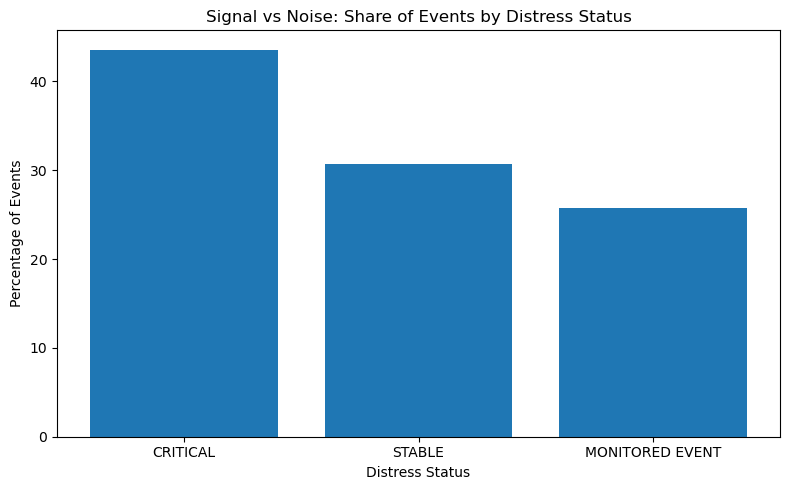

,DistressStatus,event_count,percentage
0,CRITICAL,546,43.58
1,STABLE,385,30.73
2,MONITORED EVENT,322,25.70


REPORT INTERPRETATION:
This chart shows how much of the GDELT stream represents high-risk activity versus normal or stable activity.
REPORT IMPLICATION:
If CRITICAL events are a smaller share, the pipeline is useful because it filters a noisy global stream into a smaller set of events that analysts can prioritize.


In [8]:
# ============================================================
# VISUAL 1: SIGNAL VS NOISE
# Best interpretation: How much data is actually risky?
# ============================================================

distress_totals_plot = distress_totals.copy()

if "count" in distress_totals_plot.columns:
    distress_totals_plot = distress_totals_plot.rename(columns={"count": "event_count"})

distress_totals_plot["percentage"] = (
    distress_totals_plot["event_count"] / distress_totals_plot["event_count"].sum() * 100
).round(2)

plt.figure(figsize=(8, 5))
plt.bar(distress_totals_plot["DistressStatus"], distress_totals_plot["percentage"])
plt.title("Signal vs Noise: Share of Events by Distress Status")
plt.xlabel("Distress Status")
plt.ylabel("Percentage of Events")
plt.tight_layout()
plt.show()

display(distress_totals_plot)

print("REPORT INTERPRETATION:")
print("This chart shows how much of the GDELT stream represents high-risk activity versus normal or stable activity.")
print("REPORT IMPLICATION:")
print("If CRITICAL events are a smaller share, the pipeline is useful because it filters a noisy global stream into a smaller set of events that analysts can prioritize.")

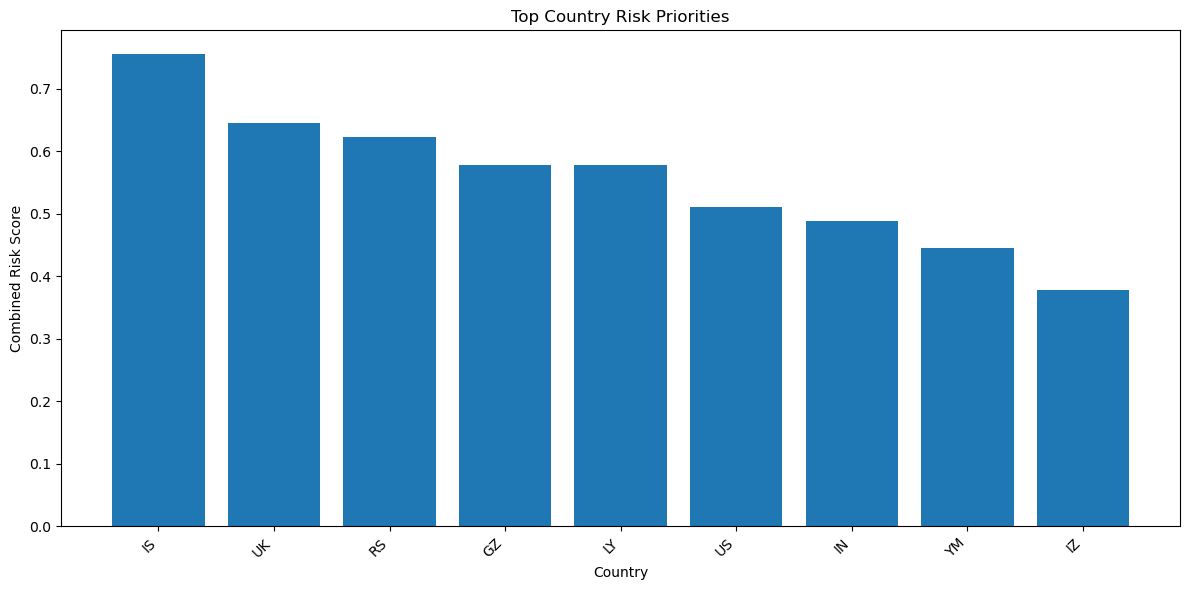

,Country,event_count,avg_tone,avg_goldstein,combined_risk_score
0,IS,455,-4.04,1.78,0.755556
2,UK,213,-2.32,1.20,0.644444
3,RS,103,-3.76,1.41,0.622222
5,GZ,6,-4.45,3.00,0.577778
8,LY,1,-4.41,1.00,0.577778
1,US,402,-1.08,1.54,0.511111
4,IN,65,-1.29,1.11,0.488889
7,YM,2,-2.29,1.00,0.444444
6,IZ,6,-0.38,1.00,0.377778


REPORT INTERPRETATION:
This chart ranks countries using event volume, average tone, and Goldstein conflict score together.
REPORT IMPLICATION:
This is better than using event count alone because it identifies countries that are both visible and negatively framed in the event stream.


In [9]:
# ============================================================
# VISUAL 2: COUNTRY PRIORITY SCORE
# Best interpretation: Which countries need attention first?
# ============================================================

risk_df = country_totals.copy()

risk_df["volume_score"] = risk_df["event_count"].rank(pct=True)
risk_df["tone_risk_score"] = (-risk_df["avg_tone"]).rank(pct=True)
risk_df["goldstein_risk_score"] = (-risk_df["avg_goldstein"]).rank(pct=True)

risk_df["combined_risk_score"] = (
    risk_df["volume_score"] * 0.40 +
    risk_df["tone_risk_score"] * 0.40 +
    risk_df["goldstein_risk_score"] * 0.20
)

risk_top = risk_df.sort_values("combined_risk_score", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(risk_top["Country"], risk_top["combined_risk_score"])
plt.title("Top Country Risk Priorities")
plt.xlabel("Country")
plt.ylabel("Combined Risk Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(risk_top[["Country", "event_count", "avg_tone", "avg_goldstein", "combined_risk_score"]])

print("REPORT INTERPRETATION:")
print("This chart ranks countries using event volume, average tone, and Goldstein conflict score together.")
print("REPORT IMPLICATION:")
print("This is better than using event count alone because it identifies countries that are both visible and negatively framed in the event stream.")

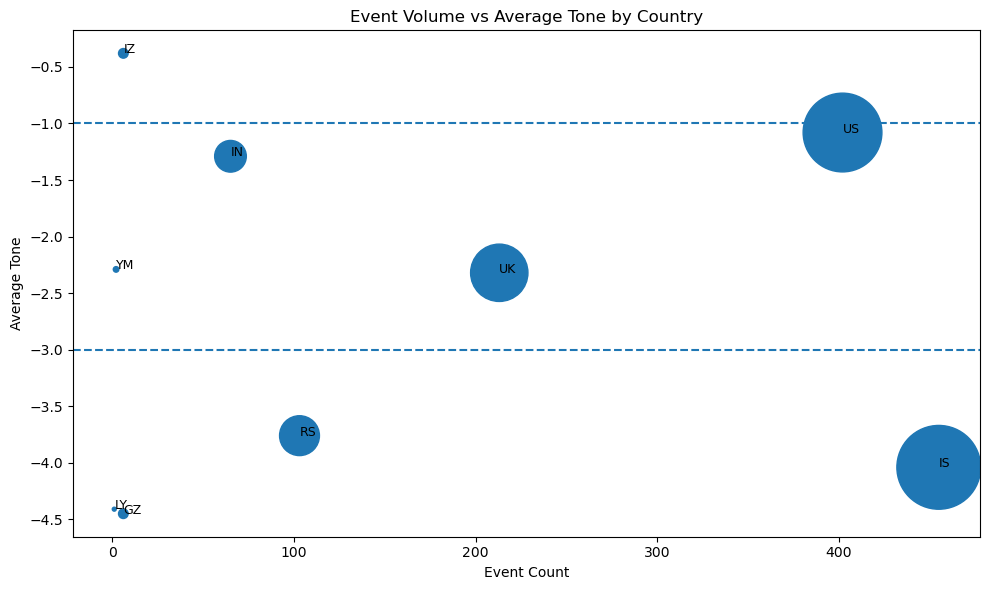

REPORT INTERPRETATION:
Countries in the high-volume and low-tone area represent stronger distress signals.
REPORT IMPLICATION:
High event count alone may only show media attention. Combining volume with tone helps identify where the news activity is more negative and potentially more urgent.


In [11]:
# ============================================================
# VISUAL 3: EVENT VOLUME VS AVERAGE TONE
# Best interpretation: media attention vs actual negative signal
# ============================================================

top_volume = country_totals.sort_values("event_count", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.scatter(top_volume["event_count"], top_volume["avg_tone"], s=top_volume["event_count"] * 8)

for _, row in top_volume.iterrows():
    plt.text(row["event_count"], row["avg_tone"], row["Country"], fontsize=9)

plt.axhline(-3, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.title("Event Volume vs Average Tone by Country")
plt.xlabel("Event Count")
plt.ylabel("Average Tone")
plt.tight_layout()
plt.show()

print("REPORT INTERPRETATION:")
print("Countries in the high-volume and low-tone area represent stronger distress signals.")
print("REPORT IMPLICATION:")
print("High event count alone may only show media attention. Combining volume with tone helps identify where the news activity is more negative and potentially more urgent.")

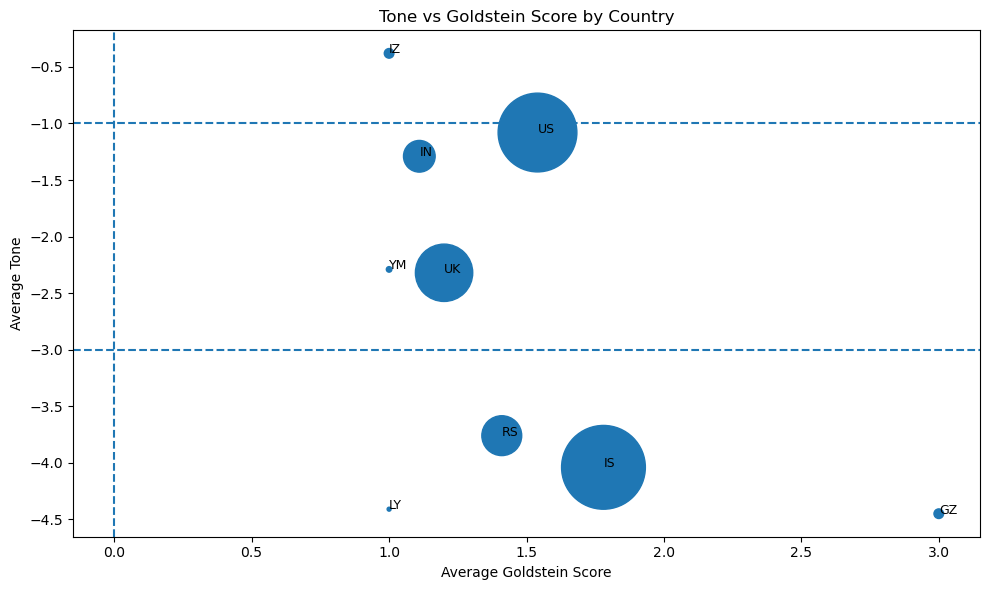

REPORT INTERPRETATION:
Tone captures negative language in reporting, while Goldstein captures whether events are more cooperative or conflict-oriented.
REPORT IMPLICATION:
Countries with both negative tone and negative Goldstein scores are stronger candidates for geopolitical or humanitarian concern.


In [13]:
# ============================================================
# VISUAL 4: TONE VS GOLDSTEIN
# Best interpretation: sentiment vs conflict severity
# ============================================================

top_volume = country_totals.sort_values("event_count", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.scatter(top_volume["avg_goldstein"], top_volume["avg_tone"], s=top_volume["event_count"] * 8)

for _, row in top_volume.iterrows():
    plt.text(row["avg_goldstein"], row["avg_tone"], row["Country"], fontsize=9)

plt.axhline(-3, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.axvline(0, linestyle="--")
plt.title("Tone vs Goldstein Score by Country")
plt.xlabel("Average Goldstein Score")
plt.ylabel("Average Tone")
plt.tight_layout()
plt.show()

print("REPORT INTERPRETATION:")
print("Tone captures negative language in reporting, while Goldstein captures whether events are more cooperative or conflict-oriented.")
print("REPORT IMPLICATION:")
print("Countries with both negative tone and negative Goldstein scores are stronger candidates for geopolitical or humanitarian concern.")

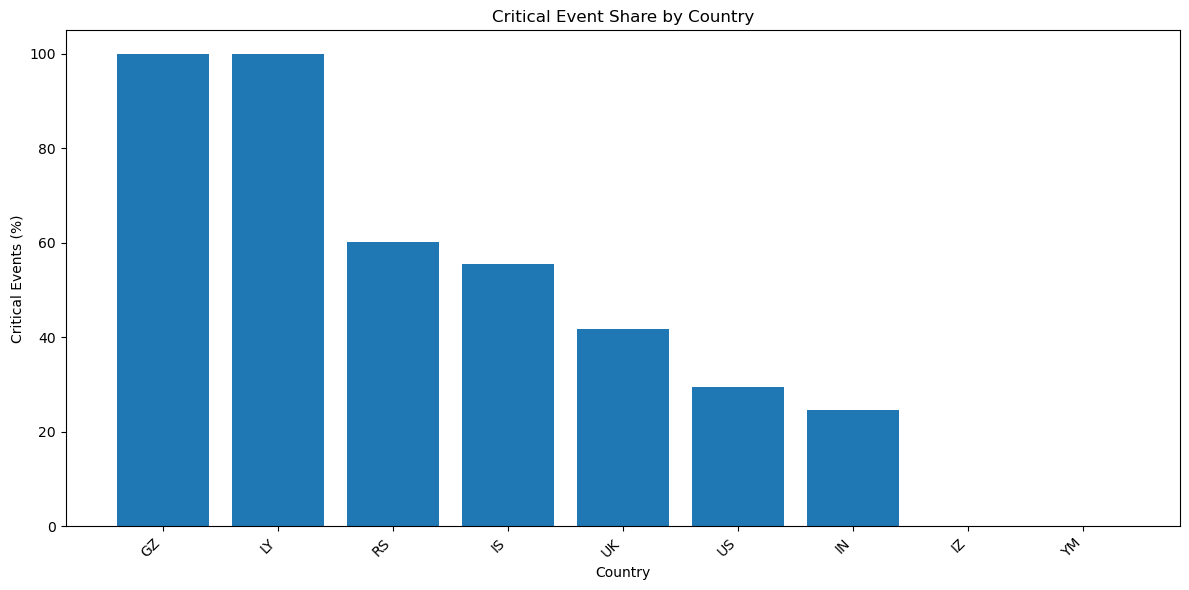

DistressStatus,CRITICAL,total_events,critical_share_pct
Country,,,
GZ,6,6,100.00
LY,1,1,100.00
RS,62,103,60.19
IS,253,455,55.60
UK,89,213,41.78
US,119,402,29.60
IN,16,65,24.62
IZ,0,6,0.00
YM,0,2,0.00


REPORT INTERPRETATION:
This chart shows which countries have the highest proportion of CRITICAL events.
REPORT IMPLICATION:
A country may have fewer total events but still deserve attention if a large percentage of its events are classified as CRITICAL.


In [14]:
# ============================================================
# VISUAL 5: CRITICAL EVENT SHARE BY COUNTRY
# Best interpretation: severity percentage, not just raw count
# ============================================================

breakdown = country_breakdown.copy()

pivot = breakdown.pivot_table(
    index="Country",
    columns="DistressStatus",
    values="event_count",
    aggfunc="sum",
    fill_value=0
)

if "CRITICAL" not in pivot.columns:
    pivot["CRITICAL"] = 0

pivot["total_events"] = pivot.sum(axis=1)
pivot["critical_share_pct"] = (pivot["CRITICAL"] / pivot["total_events"] * 100).round(2)

critical_share = pivot.sort_values("critical_share_pct", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(critical_share.index, critical_share["critical_share_pct"])
plt.title("Critical Event Share by Country")
plt.xlabel("Country")
plt.ylabel("Critical Events (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(critical_share[["CRITICAL", "total_events", "critical_share_pct"]])

print("REPORT INTERPRETATION:")
print("This chart shows which countries have the highest proportion of CRITICAL events.")
print("REPORT IMPLICATION:")
print("A country may have fewer total events but still deserve attention if a large percentage of its events are classified as CRITICAL.")

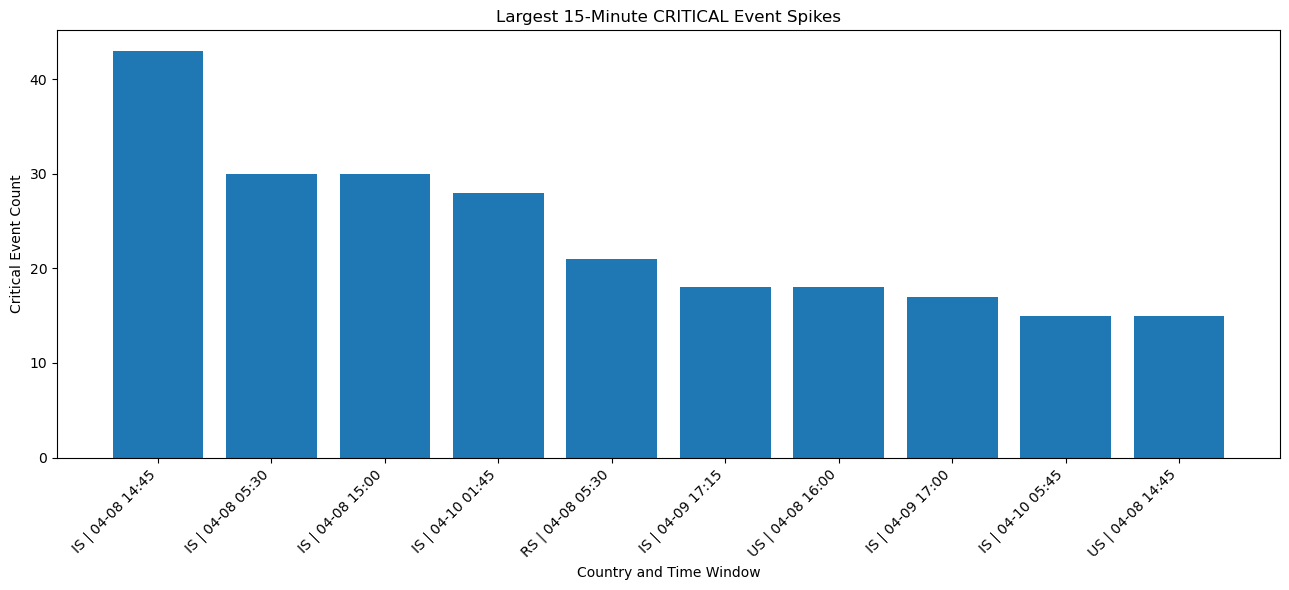

,Country,window_start,event_count,avg_tone,avg_goldstein
38,IS,2026-04-08 14:45:00,43,-5.78,1.72
16,IS,2026-04-08 05:30:00,30,-5.27,1.00
50,IS,2026-04-08 15:00:00,30,-6.61,2.23
111,IS,2026-04-10 01:45:00,28,-6.43,2.11
21,RS,2026-04-08 05:30:00,21,-5.45,0.86
90,IS,2026-04-09 17:15:00,18,-5.50,1.83
72,US,2026-04-08 16:00:00,18,-5.86,1.11
78,IS,2026-04-09 17:00:00,17,-5.76,2.06
120,IS,2026-04-10 05:45:00,15,-7.54,1.47
47,US,2026-04-08 14:45:00,15,-4.58,1.47


REPORT INTERPRETATION:
This chart identifies short windows where CRITICAL events suddenly increased.
REPORT IMPLICATION:
These spikes show the value of streaming analysis because the system can flag emerging situations quickly instead of waiting for a static end-of-day report.


In [15]:
# ============================================================
# VISUAL 6: 15-MINUTE CRITICAL SPIKES
# Best interpretation: real-time alerting value
# ============================================================

critical_spikes = event_distress[event_distress["DistressStatus"] == "CRITICAL"].copy()

if len(critical_spikes) > 0:
    critical_spikes = critical_spikes.sort_values("event_count", ascending=False).head(10)

    critical_spikes["label"] = (
        critical_spikes["Country"] + " | " +
        critical_spikes["window_start"].dt.strftime("%m-%d %H:%M")
    )

    plt.figure(figsize=(13, 6))
    plt.bar(critical_spikes["label"], critical_spikes["event_count"])
    plt.title("Largest 15-Minute CRITICAL Event Spikes")
    plt.xlabel("Country and Time Window")
    plt.ylabel("Critical Event Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(critical_spikes[["Country", "window_start", "event_count", "avg_tone", "avg_goldstein"]])

    print("REPORT INTERPRETATION:")
    print("This chart identifies short windows where CRITICAL events suddenly increased.")
    print("REPORT IMPLICATION:")
    print("These spikes show the value of streaming analysis because the system can flag emerging situations quickly instead of waiting for a static end-of-day report.")
else:
    print("No CRITICAL events found in the current output.")

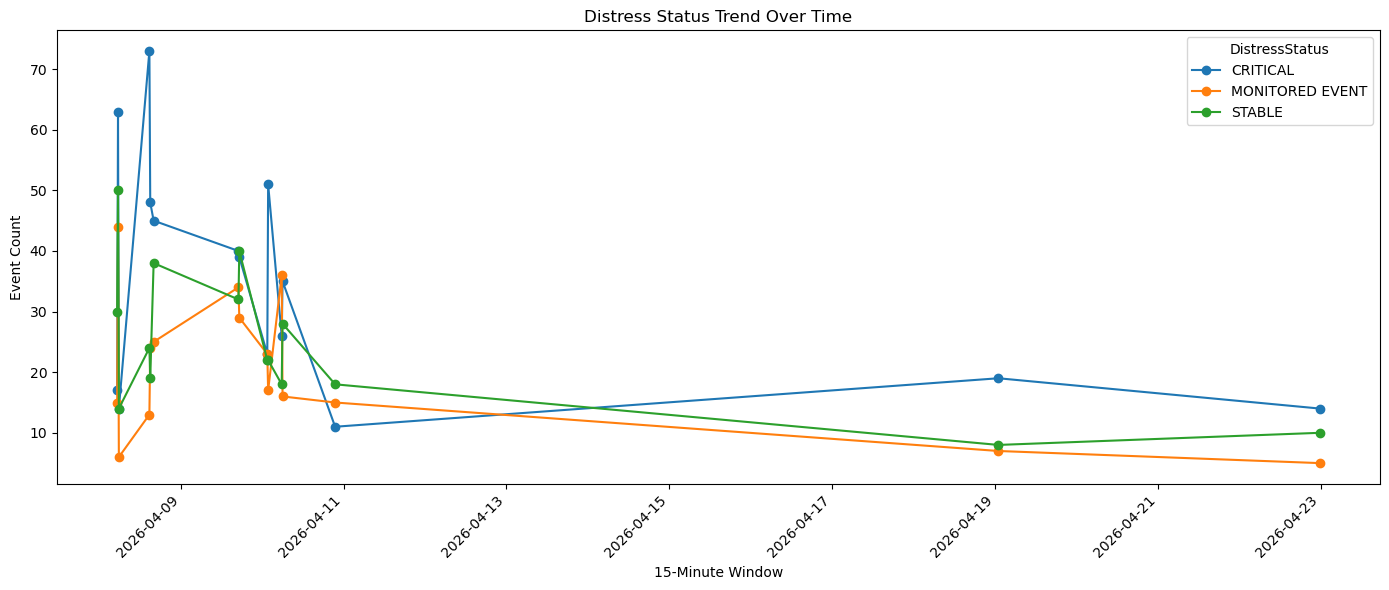

REPORT INTERPRETATION:
This chart shows how CRITICAL, MONITORED EVENT, and STABLE events change across streaming windows.
REPORT IMPLICATION:
An increase from STABLE or MONITORED EVENT toward CRITICAL can indicate escalation and can support early-warning monitoring.


In [16]:
# ============================================================
# VISUAL 7: DISTRESS TREND OVER TIME
# Best interpretation: whether risk is increasing or decreasing
# ============================================================

distress_trend = event_distress.groupby(
    ["window_start", "DistressStatus"]
)["event_count"].sum().reset_index()

pivot_trend = distress_trend.pivot_table(
    index="window_start",
    columns="DistressStatus",
    values="event_count",
    aggfunc="sum",
    fill_value=0
).sort_index()

pivot_trend.plot(kind="line", figsize=(14, 6), marker="o")
plt.title("Distress Status Trend Over Time")
plt.xlabel("15-Minute Window")
plt.ylabel("Event Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("REPORT INTERPRETATION:")
print("This chart shows how CRITICAL, MONITORED EVENT, and STABLE events change across streaming windows.")
print("REPORT IMPLICATION:")
print("An increase from STABLE or MONITORED EVENT toward CRITICAL can indicate escalation and can support early-warning monitoring.")